# Amatrice Paper Experiment Guide (TCN & GRU – Multi-Dataset)

This notebook implements the full experiment workflow for the Amatrice paper using:

- **TCN (Temporal Convolutional Network)** as one sequence model
- **GRU (Gated Recurrent Unit)** as another sequence model for comparison
- **NDI** and **log-NDI** scoring modes
- **Multiple observation products** (phase-STD and various coherence types)
- **Histogram-matching ablation**: every dataset is built *with* and *without* histogram matching to evaluate its effect

### Experiment design

Both **TCN** and **GRU** are trained on identical datasets (with and without histogram matching).
By comparing the AUC / F1 results we can answer two questions:

1. **Does histogram matching help?** — compare `<name>` vs `<name>_hm` for the same model.
2. **Which architecture generalises better?** — compare TCN vs GRU on the same dataset.

### Observation products

| Observation file | Metric | Dataset base name |
|---|---|---|
| `filt_fine.std` | phase_std | `dataset_rnn_filt_fine_std` |
| `fine.cor.full` | coherence | `dataset_rnn_fine_cor_full` |
| `filt_fine.cor` | coherence | `dataset_rnn_filt_fine_cor` |
| `unfilt_fine.cor` | coherence | `dataset_rnn_unfilt_fine_cor` |
| `underamp_unfilt_fine.cor` | coherence | `dataset_rnn_underamp_unfilt_fine_cor` |
| `underamp_unfilt_fine_circ.cor` | coherence | `dataset_rnn_underamp_unfilt_fine_circ_cor` |

Each dataset is built in two variants:
- **`<name>`** – no histogram matching
- **`<name>_hm`** – with histogram matching (median strategy)

Training distributes across **4 GPUs** (CUDA_VISIBLE_DEVICES 0–3) in round-robin fashion.

In [1]:
from pathlib import Path
import json
import os
import shlex
import subprocess

BASE_DIR = Path('/scratch/yangyanchen/amatrice2025/')
GEOM_REF_DIR = Path('/scratch/yangyanchen/amatrice2025/')
CROPPED_DIR = BASE_DIR / 'cropped_paper_bbox'
EVENT_DATE = '20160824'
NEXT_DATE = '20160821_20160914'
LAT_MIN, LAT_MAX = 42.6, 42.7
LON_MIN, LON_MAX = 13.2, 13.4

# GPU allocation – experiments are distributed across these GPUs round-robin.
GPU_IDS = [0, 1, 2, 3]
NUM_GPUS = len(GPU_IDS)

# ---- TCN hyper-parameters (easy to adjust in one place) --------------------
TCN_EPOCHS        = 30
TCN_HIDDEN_DIM    = 128
TCN_NUM_LAYERS    = 4
TCN_KERNEL_SIZE   = 3
TCN_DROPOUT       = 0.15
TCN_LR            = 5e-4
TCN_LOSS          = 'huber'
TCN_OPTIMIZER     = 'adamw'
TCN_WEIGHT_DECAY  = 1e-4
TCN_MAX_GRAD_NORM = 1.0
TCN_TRAIN_BATCH   = 256
TCN_PRED_BATCH    = 512
# ---------------------------------------------------------------------------

# ---- GRU hyper-parameters -------------------------------------------------
GRU_EPOCHS        = 30
GRU_HIDDEN_DIM    = 128
GRU_NUM_LAYERS    = 2
GRU_DROPOUT       = 0.15
GRU_LR            = 5e-4
GRU_LOSS          = 'huber'
GRU_OPTIMIZER     = 'adamw'
GRU_WEIGHT_DECAY  = 1e-4
GRU_MAX_GRAD_NORM = 1.0
GRU_TRAIN_BATCH   = 256
GRU_PRED_BATCH    = 512
# ---------------------------------------------------------------------------


def run_cmd(cmd: str, env=None):
    print(f"[RUN] {cmd}")
    merged_env = os.environ.copy()
    merged_env['PYTHONUNBUFFERED'] = '1'
    if env:
        merged_env.update(env)

    proc = subprocess.Popen(
        cmd,
        shell=True,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        env=merged_env,
        bufsize=1,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end='')
    return_code = proc.wait()
    if return_code != 0:
        raise RuntimeError(f'Command failed with code {return_code}')


try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'CPU'
except Exception:
    GPU_AVAILABLE = False
    DEVICE_NAME = 'CPU'

print('BASE_DIR =', BASE_DIR)
print('CROPPED_DIR =', CROPPED_DIR)
print('EVENT_DATE =', EVENT_DATE)
print('NEXT_DATE =', NEXT_DATE)
print(f'GPU_IDS = {GPU_IDS}  (NUM_GPUS = {NUM_GPUS})')
print('Training device policy = CUDA if available else CPU')
print('Detected device =', DEVICE_NAME)

BASE_DIR = /scratch/yangyanchen/amatrice2025
CROPPED_DIR = /scratch/yangyanchen/amatrice2025/cropped_paper_bbox
EVENT_DATE = 20160824
NEXT_DATE = 20160821_20160914
GPU_IDS = [0, 1, 2, 3]  (NUM_GPUS = 4)
Training device policy = CUDA if available else CPU
Detected device = NVIDIA A40


## 1. Crop interferogram pairs to the paper bounding box


In [10]:
run_cmd(
    f"python -m insar_pipeline.app --step crop "
    f"--base-dir {BASE_DIR} "
    f"--geom-reference-dir {GEOM_REF_DIR} "
    f"--cropped-dir {CROPPED_DIR} "
    f"--output-dir {CROPPED_DIR} "
    f"--lat-min {LAT_MIN} --lat-max {LAT_MAX} "
    f"--lon-min {LON_MIN} --lon-max {LON_MAX}"
)

[RUN] python -m insar_pipeline.app --step crop --base-dir /scratch/yangyanchen/amatrice2025 --geom-reference-dir /scratch/yangyanchen/amatrice2025 --cropped-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --lat-min 42.6 --lat-max 42.7 --lon-min 13.2 --lon-max 13.4

[SARcoherenceDPM v0.3.0] [STEP] crop
Traceback (most recent call last):
  File "/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/runpy.py", line 194, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/scratch/yangyanchen/amatrice2025/SARcoherenceDPM-main/insar_pipeline/app.py", line 707, in <module>
    main()
  File "/scratch/yangyanchen/amatrice2025/SARcoherenceDPM-main/insar_pipeline/app.py", line 703, in main
    run_step(args)
  File "/scratch/yangyanchen/amatrice2025/SARcohere

RuntimeError: Command failed with code 1

## 2. Generate INT-derived auxiliary products

Prepares the `filt_fine.std` and related auxiliary products from INT files.


In [ ]:
run_cmd(
    f"python -m insar_pipeline.app --step prepare_int_aux "
    f"--cropped-dir {CROPPED_DIR} "
    f"--output-dir {CROPPED_DIR} "
    f"--aux-corr-win 5 --aux-phsig-win 5 "
    f"--aux-variance-win 5 --aux-variance-looks 3"
)

## 3. Inspect prepared products


In [ ]:
run_cmd(f"find {CROPPED_DIR} -maxdepth 1 -type f | sort")

[RUN] find /scratch/yangyanchen/amatrice2025/cropped_paper_bbox -maxdepth 1 -type f | sort
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.cor
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.cor.vrt
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.cor.xml
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.hdr
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.int
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.int.vrt
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.int.xml
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.std
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_underamp_unfilt_fine_circ.cor
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_underamp_unfilt_fine_circ.cor.v

## 4. Build datasets

Build RNN datasets for **all observation products**, each with two variants:
- Without histogram matching (original distribution)
- With histogram matching (`_hm` suffix, median strategy)

In [ ]:
# ---- Dataset definitions ---------------------------------------------------
DATASET_SPECS = [
    {
        'observation_file': 'filt_fine.std',
        'metric': 'phase_std',
        'dataset_name': 'dataset_rnn_filt_fine_std',
    },
    {
        'observation_file': 'fine.cor.full',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_fine_cor_full',
    },
    {
        'observation_file': 'filt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_filt_fine_cor',
    },
    {
        'observation_file': 'unfilt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_unfilt_fine_cor',
    },
    {
        'observation_file': 'underamp_unfilt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_underamp_unfilt_fine_cor',
    },
    {
        'observation_file': 'underamp_unfilt_fine_circ.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_underamp_unfilt_fine_circ_cor',
    },
]

# Build each dataset in two variants: without and with histogram matching
for spec in DATASET_SPECS:
    obs = spec['observation_file']
    base_name = spec['dataset_name']

    # --- Variant 1: no histogram matching -----------------------------------
    run_cmd(
        f"python -m insar_pipeline.app --step build_dataset "
        f"--cropped-dir {CROPPED_DIR} --output-dir {CROPPED_DIR} "
        f"--event-date {EVENT_DATE} --observation-file {obs} "
        f"--dataset-name {base_name}"
    )

    # --- Variant 2: with histogram matching (median strategy) ---------------
    run_cmd(
        f"python -m insar_pipeline.app --step build_dataset "
        f"--cropped-dir {CROPPED_DIR} --output-dir {CROPPED_DIR} "
        f"--event-date {EVENT_DATE} --observation-file {obs} "
        f"--dataset-name {base_name}_hm "
        f"--histogram-match --histogram-match-strategy median"
    )

# Validate all built datasets
run_cmd(
    f"python -m insar_pipeline.app --step validate_dataset "
    f"--output-dir {CROPPED_DIR}"
)

[RUN] python -m insar_pipeline.app --step build_dataset --cropped-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --event-date 20160824 --observation-file filt_fine.std --dataset-name dataset_rnn_filt_fine_std

[SARcoherenceDPM v0.3.0] [STEP] build_dataset
  - dataset_dir: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std
[RUN] python -m insar_pipeline.app --step build_dataset --cropped-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --event-date 20160824 --observation-file filt_fine.std --dataset-name dataset_rnn_filt_fine_std_hm --histogram-match --histogram-match-strategy median

[SARcoherenceDPM v0.3.0] [STEP] build_dataset
  - dataset_dir: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std_hm
[RUN] python -m insar_pipeline.app --step build_dataset --cropped-dir /scratch/yangyan

In [2]:
# ============================================================
# Stepwise GRU Training & Scoring — 多 GPU 并行版（实时输出）
# ============================================================
import os
import threading
import subprocess
import sys
from collections import defaultdict

# ---------- Stepwise GRU 超参 ----------
# 注意：stepwise_gru 强制 scaler_type="none"，loss 固定为 stepwise_mse
# --loss-type 参数对 stepwise_gru 无效（代码中 stepwise 分支优先级最高）
SGRU_EPOCHS       = 15
SGRU_LR           = 1e-3
SGRU_OPTIMIZER    = 'adam'
SGRU_WEIGHT_DECAY = 0.0
SGRU_MAX_GRAD_NORM = 1.0
SGRU_HIDDEN_DIM   = 256      # 原论文 dpm-rnn 默认 256
SGRU_NUM_LAYERS   = 1        # 原论文 dpm-rnn 默认 1
SGRU_DROPOUT      = 0.0      # 单层 GRU dropout 不生效，设 0
SGRU_TRAIN_BATCH  = 128
SGRU_PRED_BATCH   = 256

# ---------- 1. 实验定义 ----------
SGRU_EXPERIMENTS = [
    {
        'observation_file': 'filt_fine.std',
        'metric': 'phase_std',
        'dataset_name': 'dataset_rnn_filt_fine_std',
        'timestamp_modes': ['time', 'notime'],
    },
    {
        'observation_file': 'fine.cor.full',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_fine_cor_full',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'filt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_filt_fine_cor',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'unfilt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_unfilt_fine_cor',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'underamp_unfilt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_underamp_unfilt_fine_cor',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'underamp_unfilt_fine_circ.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_underamp_unfilt_fine_circ_cor',
        'timestamp_modes': ['time'],
    },
]

SGRU_HM_VARIANTS = ['', '_hm']

# ---------- 2. 构建全部 job 并按 GPU 分组 ----------
sgru_all_jobs = []
for exp in SGRU_EXPERIMENTS:
    for hm_suffix in SGRU_HM_VARIANTS:
        for timestamp_flag in exp['timestamp_modes']:
            sgru_all_jobs.append((exp, hm_suffix, timestamp_flag))

gpu_jobs = defaultdict(list)

for job_idx, (exp, hm_suffix, timestamp_flag) in enumerate(sgru_all_jobs):
    gpu_id = GPU_IDS[job_idx % NUM_GPUS]
    disable = '--disable-timestamp' if timestamp_flag == 'notime' else ''
    metric_tag = exp['metric']
    time_tag = timestamp_flag
    dataset_dir = CROPPED_DIR / f"{exp['dataset_name']}{hm_suffix}"
    hm_label = '_hm' if hm_suffix else ''
    safe_obs = exp['observation_file'].replace('.', '_')
    score_filename = f"stepwise_gru_{time_tag}_{safe_obs}{hm_label}_ndi_score.npy"

    # ---- 关键改动：--ts-model stepwise_gru ----
    # 不传 --loss-type（stepwise_gru 忽略它，固定用 stepwise_mse）
    train_cmd = (
        f"python -u -m insar_pipeline.app --step train_predict "
        f"--dataset-dir {dataset_dir} "
        f"--output-dir {CROPPED_DIR} "
        f"--next-date {NEXT_DATE} "
        f"--timeseries-metric {metric_tag} "
        f"--ts-model stepwise_gru "
        f"--optimizer {SGRU_OPTIMIZER} --weight-decay {SGRU_WEIGHT_DECAY} "
        f"--max-grad-norm {SGRU_MAX_GRAD_NORM} "
        f"--epochs {SGRU_EPOCHS} "
        f"--lr {SGRU_LR} "
        f"--rnn-hidden-dim {SGRU_HIDDEN_DIM} --rnn-num-layers {SGRU_NUM_LAYERS} "
        f"--rnn-dropout {SGRU_DROPOUT} "
        f"--train-batch-size {SGRU_TRAIN_BATCH} --pred-batch-size {SGRU_PRED_BATCH} "
        f"--artifact-tag {safe_obs}{hm_label} "
        f"{disable}"
    )

    score_cmd = (
        f"python -u -m insar_pipeline.app --step score "
        f"--dataset-dir {dataset_dir} "
        f"--output-dir {CROPPED_DIR} "
        f"--timeseries-metric {metric_tag} "
        f"--ts-model stepwise_gru "
        f"--score-mode ndi "
        f"--score-filename {score_filename} "
        f"--artifact-tag {safe_obs}{hm_label} "
        f"{disable}"
    )

    label = f"obs={exp['observation_file']} hm={bool(hm_suffix)} ts={time_tag}"
    gpu_jobs[gpu_id].append((train_cmd, score_cmd, label, score_filename))

print(f"Total jobs: {len(sgru_all_jobs)}, GPUs: {NUM_GPUS}, "
      f"~{len(sgru_all_jobs) // NUM_GPUS} jobs/GPU")
for gid in sorted(gpu_jobs):
    print(f"  GPU {gid}: {len(gpu_jobs[gid])} jobs")

# ---------- 3. 实时流式输出的执行函数 ----------
_lock = threading.Lock()

def run_stream(cmd, env, gpu_id):
    proc = subprocess.Popen(
        cmd, shell=True, env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in proc.stdout:
        with _lock:
            print(f"[GPU {gpu_id}] {line}", end='', flush=True)
    proc.wait()
    return proc.returncode

# ---------- 4. 每个 GPU 一个 worker ----------
def gpu_worker(gpu_id, jobs):
    env = {**os.environ, "CUDA_VISIBLE_DEVICES": str(gpu_id)}
    for i, (train_cmd, score_cmd, label, score_fn) in enumerate(jobs, 1):
        with _lock:
            print(f"\n{'=' * 80}", flush=True)
            print(f"[GPU {gpu_id}] ({i}/{len(jobs)}) TRAIN START — {label}",
                  flush=True)
            print(f"{'=' * 80}", flush=True)

        rc = run_stream(train_cmd, env, gpu_id)
        if rc != 0:
            with _lock:
                print(f"[GPU {gpu_id}] ❌ TRAIN FAILED (rc={rc}) — {label}",
                      flush=True)
            continue

        with _lock:
            print(f"[GPU {gpu_id}] ({i}/{len(jobs)}) SCORE START — {label}",
                  flush=True)

        rc = run_stream(score_cmd, env, gpu_id)
        if rc != 0:
            with _lock:
                print(f"[GPU {gpu_id}] ❌ SCORE FAILED (rc={rc}) — {label}",
                      flush=True)
        else:
            with _lock:
                print(f"[GPU {gpu_id}] ✅ DONE — predict/{score_fn}",
                      flush=True)

# ---------- 5. 启动并行 ----------
threads = []
for gpu_id in sorted(gpu_jobs):
    t = threading.Thread(target=gpu_worker,
                         args=(gpu_id, gpu_jobs[gpu_id]),
                         name=f"gpu-{gpu_id}")
    t.start()
    threads.append(t)

for t in threads:
    t.join()

print('\n' + '=' * 80)
print('✅ All Stepwise GRU training & scoring jobs finished.')
print('=' * 80)

Total jobs: 14, GPUs: 4, ~3 jobs/GPU
  GPU 0: 4 jobs
  GPU 1: 4 jobs
  GPU 2: 3 jobs
  GPU 3: 3 jobs

[GPU 0] (1/4) TRAIN START — obs=filt_fine.std hm=False ts=time

[GPU 1] (1/4) TRAIN START — obs=filt_fine.std hm=False ts=notime

[GPU 2] (1/3) TRAIN START — obs=filt_fine.std hm=True ts=time

[GPU 3] (1/3) TRAIN START — obs=filt_fine.std hm=True ts=notime
[GPU 0] 
[GPU 0] ================================================================
[GPU 0] [SARcoherenceDPM v0.3.0] [STEP] train_predict
[GPU 0] ================================================================
[GPU 0]   - dataset_dir: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std
[GPU 0]   - artifact_prefix: rnn_stepwise_gru_phase_std_raw_time_filt_fine_std
[GPU 0]   - param_file: None
[GPU 0]   - model: stepwise_gru
[GPU 0]   - metric: phase_std
[GPU 0]   - timestamp: enabled
[GPU 0]   - device_policy: cuda-if-available-else-cpu
[GPU 0]   - epochs: 15
[GPU 0]   - train_batch_size: 128
[GPU 0]   - pred

## 9. GRU log-NDI scoring

Reuse the GRU predictions from Section 8 (no retraining needed).
log-NDI = log(observed / predicted) for phase_std, log(predicted / observed) for coherence.
A positive value indicates damage.
Covers all observation products × histogram-match variants.

## 10. Generate geospatial output products

In [3]:
run_cmd(
    f"python -m insar_pipeline.app --step output "
    f"--predict-dir {CROPPED_DIR / 'predict'} "
    f"--output-dir {CROPPED_DIR} "
    f"--lat-file {CROPPED_DIR / 'lat_cropped.rdr'} "
    f"--lon-file {CROPPED_DIR / 'lon_cropped.rdr'} "
    f"--subset-params '-l 42.6 42.7 -L 13.2 13.4'"
)


[RUN] python -m insar_pipeline.app --step output --predict-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --lat-file /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/lat_cropped.rdr --lon-file /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/lon_cropped.rdr --subset-params '-l 42.6 42.7 -L 13.2 13.4'

[SARcoherenceDPM v0.3.0] [STEP] output
write file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/stepwise_gru_notime_filt_fine_std_hm_ndi.cor
write file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/stepwise_gru_notime_filt_fine_std_hm_ndi.cor.xml
write file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/stepwise_gru_notime_filt_fine_std_hm_ndi.cor.vrt
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/lat_cropped.rdr
calculate output pi

## 11. AUC evaluation – TCN vs GRU × histogram matching

Load all score maps and compute AUC against the ground-truth damage mask.
The evaluation covers:

- **Baseline** NDI difference scores (no model)
- **TCN** NDI and log-NDI scores (with and without histogram matching)
- **GRU** NDI and log-NDI scores (with and without histogram matching)

By comparing `_hm` vs non-`_hm` variants for the same model we can assess the
impact of histogram matching. By comparing TCN vs GRU on the same data we assess
architecture choice.

`DAMAGE_MASK_FILE` should be a binary `.npy` array (1 = damaged, 0 = undamaged) spatially aligned with the score maps.

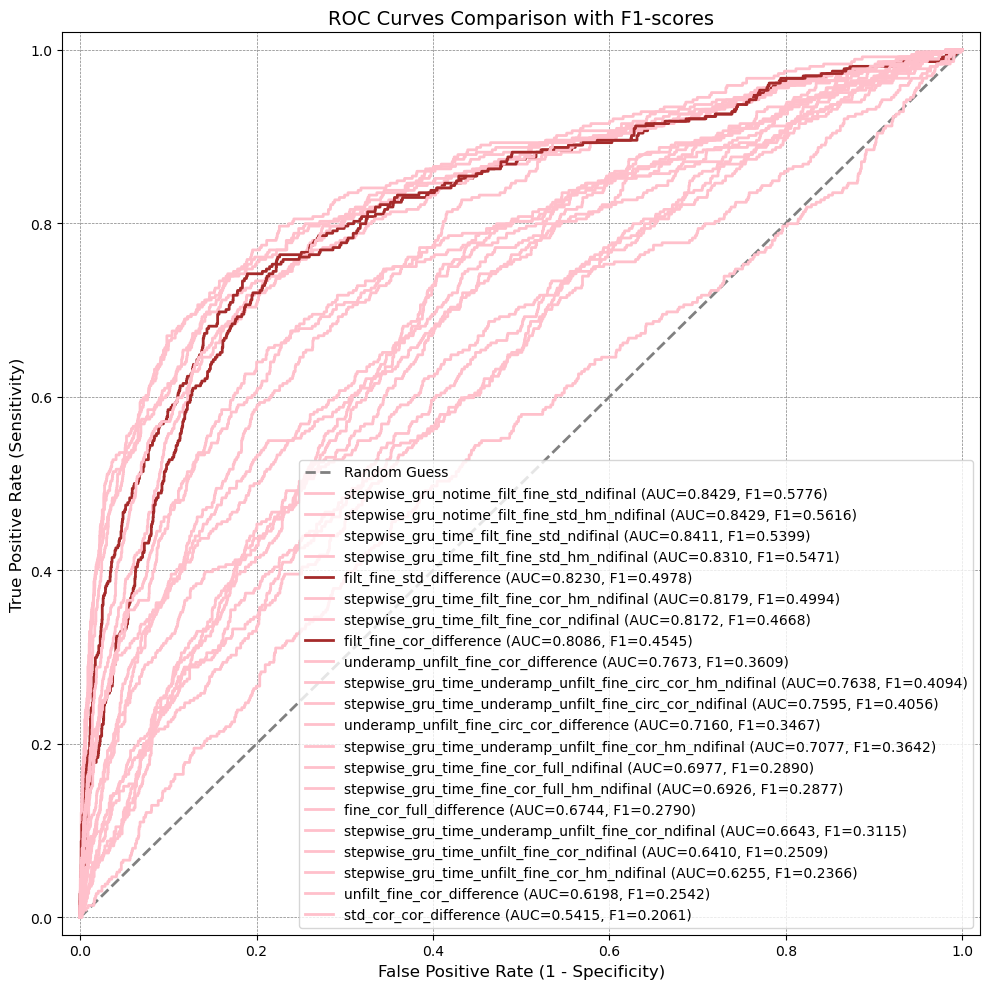


特征性能报告:
按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)
----------------------------------------------------------------------------------------------------
特征名称         AUC值         最佳F1-score      阈值              虚警率(FPR)       
----------------------------------------------------------------------------------------------------
stepwise_gru_notime_filt_fine_std_ndifinal 0.84289      0.57764         0.52176         0.03073        
stepwise_gru_notime_filt_fine_std_hm_ndifinal 0.84285      0.56156         0.41991         0.03759        
stepwise_gru_time_filt_fine_std_ndifinal 0.84114      0.53988         0.50955         0.03661        
stepwise_gru_time_filt_fine_std_hm_ndifinal 0.83096      0.54706         0.38076         0.04250        
filt_fine_std_difference 0.82303      0.49784         0.57827         0.05165        
stepwise_gru_time_filt_fine_cor_hm_ndifinal 0.81785      0.49937         0.30061         0.07650        
stepwise_gru_time_filt_fine_cor_ndifinal 0.81723      0.46680       

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix

df = pd.read_csv("/scratch/yangyanchen/amatrice2025/timeseries.csv")  # 替换为你的文件路径

# 定义特征列表和颜色配置 decorrelation	TGRS_std	TGRS


features = [
    ("filt_fine_cor_difference", "brown"),
    ("filt_fine_std_difference", "brown"),
    ("fine_cor_full_difference", "pink"),
    ("std_cor_cor_difference", "pink"),
    ("underamp_unfilt_fine_circ_cor_difference", "pink"),
    ("underamp_unfilt_fine_cor_difference", "pink"),
    ("unfilt_fine_cor_difference", "pink"),
    ("stepwise_gru_notime_filt_fine_std_hm_ndifinal", "pink"),
    ("stepwise_gru_notime_filt_fine_std_ndifinal", "pink"),
    ("stepwise_gru_time_filt_fine_cor_hm_ndifinal", "pink"),
    ("stepwise_gru_time_filt_fine_cor_ndifinal", "pink"),
    ("stepwise_gru_time_filt_fine_std_hm_ndifinal", "pink"),
    ("stepwise_gru_time_filt_fine_std_ndifinal", "pink"),
    ("stepwise_gru_time_fine_cor_full_hm_ndifinal", "pink"),
    ("stepwise_gru_time_fine_cor_full_ndifinal", "pink"),
    ("stepwise_gru_time_underamp_unfilt_fine_circ_cor_hm_ndifinal", "pink"),
    ("stepwise_gru_time_underamp_unfilt_fine_circ_cor_ndifinal", "pink"),
    ("stepwise_gru_time_underamp_unfilt_fine_cor_hm_ndifinal", "pink"),
    ("stepwise_gru_time_underamp_unfilt_fine_cor_ndifinal", "pink"),
    ("stepwise_gru_time_unfilt_fine_cor_hm_ndifinal", "pink"),
    ("stepwise_gru_time_unfilt_fine_cor_ndifinal", "pink")
]
# 设置画布
plt.figure(figsize=(10, 10))

# 绘制参考线
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Guess')

# 创建列表存储计算结果
roc_data = []
f1_results = []  # 存储F1-score结果

# 先计算所有特征的AUC值和F1-score
for feature, color in features:
    y_true = df['damaged']
    y_score = df[feature]
    
    # 计算ROC曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 找到最佳F1-score及其阈值
    best_f1 = 0
    best_threshold = 0
    best_fpr = 0
    best_f1_index = 0
    
    # 遍历所有阈值计算F1-score
    for i, threshold in enumerate(thresholds):
        # 使用当前阈值进行预测
        y_pred = (y_score >= threshold).astype(int)
        
        # 计算F1-score
        f1 = f1_score(y_true, y_pred)
        
        # 更新最佳F1-score
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_f1_index = i
    
    # 获取最佳阈值对应的虚警率(FPR)
    if best_f1_index < len(fpr):
        best_fpr = fpr[best_f1_index]
    else:
        # 如果索引越界，使用上一个可用的FPR值
        best_fpr = fpr[-1] if fpr.size > 0 else 0
    
    # 存储特征名、颜色、AUC值以及ROC曲线数据
    roc_data.append({
        'feature': feature,
        'color': color,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'best_fpr': best_fpr
    })
    
    # 存储F1结果用于后续输出
    f1_results.append({
        'feature': feature,
        'auc': roc_auc,
        'best_f1': best_f1,
        'threshold': best_threshold,
        'fpr': best_fpr
    })

# 按AUC值从高到低排序
roc_data_sorted = sorted(roc_data, key=lambda x: x['auc'], reverse=True)

# 按排序后的顺序绘制ROC曲线
for data in roc_data_sorted:
    plt.plot(data['fpr'], data['tpr'], color=data['color'], lw=2,
             label=f"{data['feature']} (AUC={data['auc']:.4f}, F1={data['best_f1']:.4f})")

# 图表装饰
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison with F1-scores', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('ROC_curves_with_F1_scores.png', dpi=300)
plt.show()

# 打印F1-score和虚警率结果
print("\n特征性能报告:")
print("按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

# 按AUC排序F1结果
f1_results_sorted = sorted(f1_results, key=lambda x: x['auc'], reverse=True)

for result in f1_results_sorted:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))

# 按F1-score排序
f1_results_sorted_by_f1 = sorted(f1_results, key=lambda x: x['best_f1'], reverse=True)

print("\n按F1-score排序:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_f1:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
# 按虚警率(FPR)排序（升序，即FPR越小越好）
f1_results_sorted_by_fpr = sorted(f1_results, key=lambda x: x['fpr'])

print("\n按虚警率(FPR)排序（从小到大）:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_fpr:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))


## 12. Histogram matching ablation summary

Pair each **`<model>_<obs>`** result with its **`<model>_<obs>_hm`** counterpart
and compute the AUC delta to quantify the impact of histogram matching per
observation product and per model architecture.

In [ ]:
# ---- Histogram matching ablation: pair HM vs non-HM for each model × obs ---
print('\n' + '=' * 110)
print('Histogram Matching Ablation  (ΔAUC = AUC_hm − AUC_raw)')
print('=' * 110)
print(f'{"Feature (raw)":<55} {"AUC_raw":>8} {"AUC_hm":>8} {"ΔAUC":>8} {"ΔF1":>8}')
print('-' * 110)

auc_map = {r['feature']: r for r in f1_results}

paired = []
for r in f1_results:
    feat = r['feature']
    # Only consider non-HM features that have an _hm counterpart
    if '_hm' in feat:
        continue
    # Try to find the _hm counterpart
    # The _hm suffix is inserted before the score type suffix
    # e.g., gru_time_filt_fine_cor_ndifinal -> gru_time_filt_fine_cor_hm_ndifinal
    for suffix in ['_logndifinal', '_ndifinal', '_logndi_score', '_ndi_score', '_difference']:
        if feat.endswith(suffix):
            base = feat[:-len(suffix)]
            hm_feat = base + '_hm' + suffix
            if hm_feat in auc_map:
                r_hm = auc_map[hm_feat]
                delta_auc = r_hm['auc'] - r['auc']
                delta_f1 = r_hm['best_f1'] - r['best_f1']
                paired.append((feat, r['auc'], r_hm['auc'], delta_auc, delta_f1))
                print(f'{feat:<55} {r["auc"]:>8.5f} {r_hm["auc"]:>8.5f} {delta_auc:>+8.5f} {delta_f1:>+8.5f}')
            break

if paired:
    avg_delta = np.mean([p[3] for p in paired])
    print('-' * 110)
    print(f'{"Average ΔAUC":<55} {"":>8} {"":>8} {avg_delta:>+8.5f}')
    print()
    if avg_delta > 0:
        print('→ On average histogram matching IMPROVES AUC.')
    elif avg_delta < 0:
        print('→ On average histogram matching HURTS AUC.')
    else:
        print('→ On average histogram matching has NO effect on AUC.')

    # Separate by model
    for model_tag in ['tcn', 'gru']:
        model_pairs = [p for p in paired if p[0].startswith(model_tag + '_')]
        if model_pairs:
            model_avg = np.mean([p[3] for p in model_pairs])
            print(f'  • {model_tag.upper()} average ΔAUC = {model_avg:+.5f}  '
                  f'({len(model_pairs)} pairs)')
else:
    print('No HM vs non-HM pairs found in the available features.')